# NLP Pipeline Project: Reddit Data Analysis

This notebook demonstrates an end-to-end NLP pipeline:
1.  **Data Collection**: Scraping Reddit for Health, Sports, and Politics data.
2.  **Preprocessing**: Cleaning and tokenizing text.
3.  **Embeddings**: Generating Word2Vec and SBERT embeddings.
4.  **Clustering**: K-Means clustering to group topics.
5.  **Evaluation**: Detailed metrics including Confusion Matrix.
6.  **Visualization**: t-SNE visualization of clusters.
7.  **Search Optimization**: Dynamic state search for efficient querying.
8.  **Performance Benchmarking**: Accuracy and speedup analysis.

In [21]:
import os
import re
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import praw
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    confusion_matrix, homogeneity_score, completeness_score, 
    v_measure_score, adjusted_rand_score
)
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

# Download NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

## 1. Data Collection
Fetching data from Reddit using PRAW.

In [22]:
def get_reddit_instance():
    # Credentials should be handled securely in production (e.g., env vars)
    reddit = praw.Reddit(
        client_id="ryZkJGgYx2wsH3cIYm6BDA",
        client_secret="t9-4UKGaybDwWtyk49zFewuHVSQEyg",
        user_agent="python:nlp_scraper:v1.0 (by /u/user)"
    )
    return reddit

def fetch_reddit_posts_by_word_count(topic, target_word_count=25000):
    reddit = get_reddit_instance()
    posts = []
    current_word_count = 0
    unique_ids = set()
    
    # Strategy: iterate through sorts and time filters
    sorts = ['relevance', 'hot', 'top', 'new']
    time_filters = ['all', 'year', 'month']
    
    print(f"Fetching posts for '{topic}' targeting {target_word_count} words...")
    
    for sort_by in sorts:
        if current_word_count >= target_word_count:
            break
            
        current_time_filters = time_filters if sort_by == 'top' else [None]
        
        for t_filter in current_time_filters:
            if current_word_count >= target_word_count:
                break
                
            print(f"  -> Scraping Sort: {sort_by}, Time: {t_filter}")
            
            try:
                if sort_by == 'relevance':
                    iterator = reddit.subreddit("all").search(topic, limit=1000)
                elif sort_by == 'hot':
                    iterator = reddit.subreddit("all").search(topic, sort='hot', limit=1000)
                elif sort_by == 'new':
                    iterator = reddit.subreddit("all").search(topic, sort='new', limit=1000)
                elif sort_by == 'top':
                    iterator = reddit.subreddit("all").search(topic, sort='top', time_filter=t_filter, limit=1000)
                
                count_this_batch = 0
                for submission in iterator:
                    if submission.id in unique_ids:
                        continue
                        
                    title = submission.title
                    selftext = submission.selftext
                    content = f"{title}\n{selftext}".strip()
                    
                    if not content:
                        continue
                        
                    word_count = len(content.split())
                    if word_count < 5: 
                        continue

                    posts.append(content)
                    unique_ids.add(submission.id)
                    current_word_count += word_count
                    count_this_batch += 1
                    
                    if current_word_count >= target_word_count:
                        break
                
                print(f"     Fetched {count_this_batch} posts. Total Words: {current_word_count}/{target_word_count}")

            except Exception as e:
                print(f"     Error in batch: {e}")
                continue

    print(f"Scrape finished. Collected {len(posts)} posts totaling {current_word_count} words for {topic}.")
    return posts

def save_data(data, topic, directory="data"):
    if not os.path.exists(directory):
        os.makedirs(directory)
    
    file_path = os.path.join(directory, f"{topic.lower()}.txt")
    with open(file_path, "w", encoding="utf-8") as f:
        for item in data:
            clean_item = item.replace("\n", " ")
            f.write(clean_item + "\n")
            
    print(f"Saved {len(data)} items for {topic} to {file_path}")

def run_crawler():
    topics = ["Health", "Sports", "Politics"]
    target_words = 25000 
    
    for topic in topics:
        file_path = os.path.join("data", f"{topic.lower()}.txt")
        data = fetch_reddit_posts_by_word_count(topic, target_word_count=target_words)
        if data:
            save_data(data, topic)

## 2. Preprocessing
Cleaning and tokenizing the text data.

In [23]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if not w in stop_words]
    return " ".join(filtered_tokens)

def process_data(directory="data"):
    all_data = []
    labels = []
    
    if not os.path.exists(directory):
        print(f"Directory {directory} does not exist.")
        return [], []

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            topic = filename.replace(".txt", "").capitalize()
            file_path = os.path.join(directory, filename)
            with open(file_path, "r", encoding="utf-8") as f:
                lines = f.readlines()
                for line in lines:
                    cleaned = clean_text(line.strip())
                    if cleaned:
                        all_data.append(cleaned)
                        labels.append(topic)
    
    return all_data, labels

## 3. Embedding Generation
Generating Word2Vec (word-level) and SBERT (sentence-level) embeddings.

In [24]:
def generate_word_embeddings(tokenized_sentences, vector_size=100, window=5, min_count=1):
    print("Training Word2Vec model...")
    model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4
    )
    return model


def generate_sentence_embeddings(sentences, model_name='all-MiniLM-L6-v2', show_samples=5):
    print(f"Loading SBERT model ({model_name})...")
    model = SentenceTransformer(model_name)

    print("Encoding sentences...")
    embeddings = model.encode(
        sentences,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # 🧾 Display sentences with their embeddings
    print("\n" + "=" * 80)
    print("SENTENCE → SBERT EMBEDDING")
    print("=" * 80)

    for i in range(min(show_samples, len(sentences))):
        print(f"\nSentence {i+1}:")
        print(sentences[i])
        print("\nEmbedding Vector:")
        print(embeddings[i])
        print("-" * 80)

    print(f"\nTotal Sentences Encoded : {len(sentences)}")
    print(f"Embedding Dimension     : {embeddings.shape[1]}")

    return embeddings, model


## 4. Clustering
Using K-Means to cluster the sentence embeddings.

In [25]:
def perform_clustering(embeddings, n_clusters=3):
    print(f"Clustering into {n_clusters} groups...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    return cluster_labels, kmeans

def evaluate_clustering(embeddings, labels):
    print("Evaluating clustering performance (Basic Metric)...")
    silhouette = silhouette_score(embeddings, labels)
    return {"Silhouette Score": silhouette}

def map_clusters_to_topics(true_labels, cluster_labels):
    topic_map = {"Health": 0, "Sports": 1, "Politics": 2}
    unique_clusters = np.unique(cluster_labels)
    
    mapping = {}
    for cluster in unique_clusters:
        indices = np.where(cluster_labels == cluster)
        labels_in_cluster = [true_labels[i] for i in indices[0]]
        if not labels_in_cluster:
            continue
        majority_topic = Counter(labels_in_cluster).most_common(1)[0][0]
        mapping[cluster] = majority_topic
    
    return mapping

## 5. Detailed Evaluation
Comparing clusters against ground truth labels.

In [26]:
def run_detailed_evaluation(embeddings, true_labels, kmeans, mapping):
    print("Predicting clusters for detailed evaluation...")
    cluster_labels = kmeans.predict(embeddings)
    predicted_labels = [mapping[label] for label in cluster_labels]
    
    # Supervised Metrics
    print("\n" + "="*40)
    print("SUPERVISED METRICS (Ground Truth vs Clusters)")
    print("="*40)
    
    homogeneity = homogeneity_score(true_labels, cluster_labels)
    completeness = completeness_score(true_labels, cluster_labels)
    v_measure = v_measure_score(true_labels, cluster_labels)
    ari = adjusted_rand_score(true_labels, cluster_labels)
    
    print(f"Homogeneity:      {homogeneity:.4f}")
    print(f"Completeness:     {completeness:.4f}")
    print(f"V-Measure:        {v_measure:.4f}")
    print(f"Adj. Rand Index:  {ari:.4f}")
    
    # Confusion Matrix
    print("\n" + "="*40)
    print("CONFUSION MATRIX")
    print("Row: True Label, Column: Predicted Cluster Label")
    print("="*40)
    
    unique_labels = sorted(list(set(true_labels)))
    cm = confusion_matrix(true_labels, predicted_labels, labels=unique_labels)
    cm_df = pd.DataFrame(cm, index=unique_labels, columns=unique_labels)
    print(cm_df)
    
    # # Unsupervised
    # sil = silhouette_score(embeddings, cluster_labels)
    # db = davies_bouldin_score(embeddings, cluster_labels)
    
    # print("\n" + "="*40)
    # print("UNSUPERVISED METRICS")
    # print("="*40)
    # print(f"Silhouette Score:        {sil:.4f}")
    # print(f"Davies-Bouldin Index:    {db:.4f}")

    # Interpretation
    print("\n" + "="*40)
    print("INTERPRETATION")
    print("="*40)
    if homogeneity > 0.8 and completeness > 0.8:
        print("SUCCESS: Clusters align very well with the original topics.")
    elif homogeneity > 0.8:
        print("GOOD: Clusters are pure, but some topics might be split.")
    elif completeness > 0.8:
        print("OK: Topics are grouped together, but clusters contain mixed topics.")
    else:
        print("WARNING: Low correlation between clusters and topics.")

## 6. Dynamic Search Optimizer
Class for handling semantic routing and optimized searching.

In [27]:
class DynamicSearchOptimizer:
    def __init__(self, kmeans_model, label_mapping, embeddings, labels, sbert_model_name='all-MiniLM-L6-v2'):
        self.kmeans = kmeans_model
        self.mapping = label_mapping
        self.all_embeddings = embeddings
        self.all_labels = labels
        self.sbert = SentenceTransformer(sbert_model_name)
        self.topic_to_id = {"Health": 0, "Sports": 1, "Politics": 2}
        
    def predict_cluster(self, prompt):
        embedding = self.sbert.encode([prompt])
        raw_cluster_id = self.kmeans.predict(embedding)[0]
        topic_name = self.mapping[raw_cluster_id]
        return self.topic_to_id.get(topic_name, -1), topic_name, embedding[0]

    def simulated_search(self, prompt_embedding, target_embeddings):
        start = time.time()
        if len(target_embeddings) == 0:
            return 0
            
        norm_a = np.linalg.norm(prompt_embedding)
        norm_b = np.linalg.norm(target_embeddings, axis=1)
        similarities = np.dot(target_embeddings, prompt_embedding) / (norm_a * norm_b + 1e-9)
        
        # Simulate processing work
        for _ in range(len(target_embeddings)):
            pass 
        return time.time() - start

## 7. Visualization
Visualizing the high-dimensional embeddings in 2D space using t-SNE.

In [28]:
def visualize_clusters(embeddings, cluster_labels, mapping):
    topic_labels = [mapping[label] for label in cluster_labels]
    
    print("Reducing dimensions (t-SNE)...")
    tsne = TSNE(n_components=2, verbose=0, random_state=42, perplexity=40, n_iter=1000)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    print("Plotting...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=reduced_embeddings[:, 0], 
        y=reduced_embeddings[:, 1], 
        hue=topic_labels, 
        palette="viridis",
        s=80,
        alpha=0.6,
        edgecolor="w", 
        linewidth=0.5
    )
    
    plt.title("Cluster Visualization (t-SNE Projection)", fontsize=18)
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    plt.legend(title="Topic", title_fontsize=12, fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.15)
    plt.show() # Display in notebook

## 8. Run Pipeline
Orchestrating the data flow.

Processing data...
Total documents: 1354
Generating embeddings...
Training Word2Vec model...
Loading SBERT model (all-MiniLM-L6-v2)...
Encoding sentences...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]


SENTENCE → SBERT EMBEDDING

Sentence 1:
blursedhealth food

Embedding Vector:
[ 1.07703300e-03 -3.22144143e-02  4.77626920e-02  4.33172919e-02
 -4.72967997e-02  1.57310616e-03  5.33716381e-02 -7.43355078e-04
 -1.04122814e-02 -8.58077928e-02  4.93014865e-02 -3.62416245e-02
 -5.19046448e-02 -8.33336934e-02 -3.89665626e-02 -9.55146328e-02
  1.33416474e-01  5.26467338e-02 -1.16300479e-01 -7.58637413e-02
  6.91762865e-02  6.07918156e-03  8.62080511e-03  2.44841781e-02
 -3.50794406e-03  1.67562962e-02  5.18040685e-03 -7.94114545e-02
 -3.38304788e-02 -2.75720078e-02  2.86738798e-02 -2.91082542e-02
  6.22369647e-02 -1.88645478e-02 -7.00752735e-02 -3.82192656e-02
  3.77626754e-02 -5.64264618e-02  1.04084089e-02 -5.46782129e-02
  1.11153780e-03 -3.84687893e-02 -4.29141857e-02  4.41666180e-03
  2.71290131e-02 -2.20022723e-02 -1.95517503e-02  1.70010235e-02
  5.01507819e-02 -5.13207279e-02 -1.03941940e-01 -5.95501512e-02
  3.33859101e-02 -3.17294747e-02  4.80260774e-02  1.76667105e-02
 -9.7643472

c:\Users\csvis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Plotting...


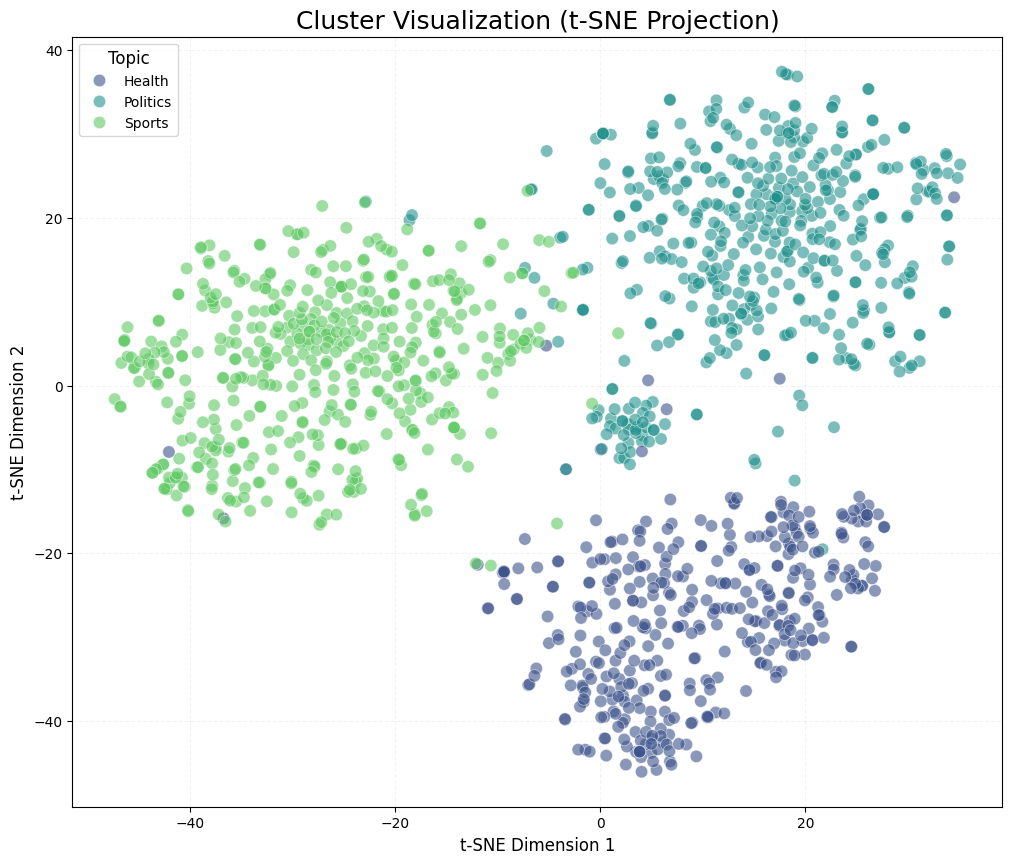

In [29]:
# --- Execution Pipeline ---

# 1. Collect Data (Comment out if already have data)
# run_crawler()

# 2. Process Data
print("Processing data...")
data, labels = process_data()
print(f"Total documents: {len(data)}")

# 3. Embeddings
print("Generating embeddings...")
tokenized_data = [d.split() for d in data]
w2v = generate_word_embeddings(tokenized_data)
sbert_emb, sbert_model = generate_sentence_embeddings(data)

# 4. Clustering
print("Clustering...")
cluster_labels, kmeans = perform_clustering(sbert_emb)

mapping = map_clusters_to_topics(labels, cluster_labels)
print(f"Mapping: {mapping}")

# 5. DETAILED EVALUATION
run_detailed_evaluation(sbert_emb, labels, kmeans, mapping)

# 6. Visualization
visualize_clusters(sbert_emb, cluster_labels, mapping)

# A clustering is homogeneous if:
Every cluster contains points from only one true class
Cluster 0 → Health only




# A clustering is complete if:
All members of a class are assigned to the same cluster
Health → Cluster 0 only


# What V-measure is
Harmonic mean of homogeneity and completeness
2ab/a+b

# ARI:

“Do pairs of points that belong together in reality also belong together in my clustering?”

Instead of thinking in terms of:
clusters
topics





a = distance to own cluster
b = distance to nearest other cluster

silhouette = (b − a) / max(a, b)

silhouette = 1 : perfect clustering
silhouette = 0 : random clustering
silhouette = -1 : worst clustering


## 9. Performance Benchmark
Evaluating the routing accuracy and search speedup.

In [30]:
# 9. Interactive Query
optimizer = DynamicSearchOptimizer(kmeans, mapping, sbert_emb, labels)

print("\n--- Interactive Semantic Router ---")
print("Enter a query to see which cluster it belongs to and the routing speedup.")
print("Type 'exit' to quit.")

while True:
    try:
        query = input("\nEnter your query: ")
        if query.lower() in ['exit', 'quit']:
            break
            
        start_t = time.time()
        tid, predicted, p_emb = optimizer.predict_cluster(query)
        pred_lat = time.time() - start_t
        
        # Performance Simulation
        SCALING_FACTOR = 1000
        
        # Traditional: Search ALL
        full_time = optimizer.simulated_search(p_emb, optimizer.all_embeddings) * SCALING_FACTOR
        
        # Optimized: Search Cluster Subset
        cluster_indices = [i for i, l in enumerate(optimizer.all_labels) if l == predicted]
        if cluster_indices:
            cluster_embs = optimizer.all_embeddings[cluster_indices]
            opt_search = optimizer.simulated_search(p_emb, cluster_embs) * SCALING_FACTOR
        else:
            opt_search = 0
            
        total_opt_time = pred_lat + opt_search
        speedup = full_time / total_opt_time if total_opt_time > 0 else 0
        
        print(f"\nQuery: '{query}'")
        print(f"Predicted Topic: {predicted}")
        print(f"Traditional Time (Est 1000x): {full_time:.4f}s")
        print(f"Optimized Time (Predicted)  : {total_opt_time:.4f}s")
        print(f"Estimated Speedup: {speedup:.2f}x")
        
    except KeyboardInterrupt:
        break


--- Interactive Semantic Router ---
Enter a query to see which cluster it belongs to and the routing speedup.
Type 'exit' to quit.

Query: 'tell me the current situation that is going in the middle east '
Predicted Topic: Politics
Traditional Time (Est 1000x): 2.1646s
Optimized Time (Predicted)  : 0.5673s
Estimated Speedup: 3.82x
